## Generate the sinthetic data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import porespy as ps

In [6]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

Random number: 95


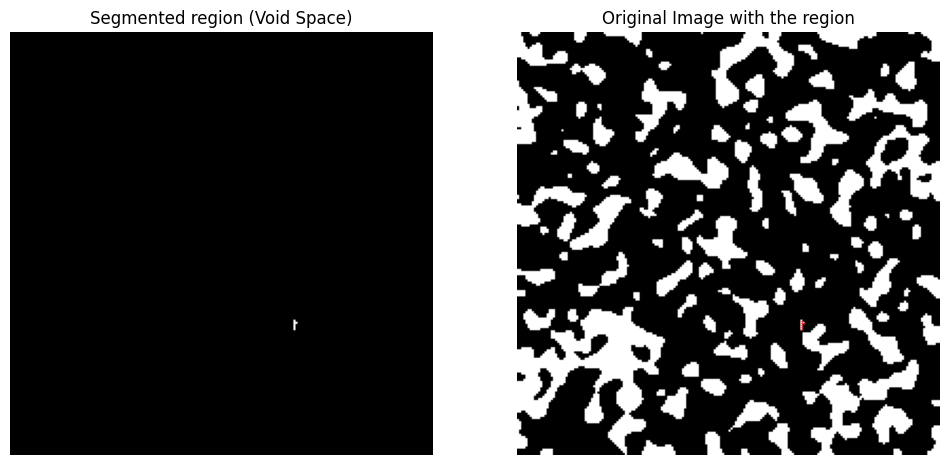

In [7]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)

import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [13]:
# The number of pixels to consider a pore
pore_number = 30

In [14]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas



# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [15]:
len(resultados_kmeans), len(contour_per_cluster), len(number_of_pores_kmeans)

(121, 121, 121)

In [16]:
set_of_pores = []
set_of_pores_index = []
set_of_iso_void = []
set_of_iso_void_index = []
# First we search the clusters that are a set of "pores"
for i in range(0, len(resultados_kmeans) - 1 ):
    if number_of_pores_kmeans[i] > 1:
        temp_save_pores = number_of_pores_kmeans[i] 
        temp_save_pores_index = i
        set_of_pores.append(temp_save_pores)
        set_of_pores_index.append(temp_save_pores_index)
    else:
        temp_save_void = number_of_pores_kmeans[i] 
        temp_save_void_index = i     
        set_of_iso_void.append(temp_save_void)
        set_of_iso_void_index.append(temp_save_void_index)

In [17]:
# Checking the length of each list
len(set_of_pores), len(set_of_pores_index), len(set_of_iso_void), len(set_of_iso_void_index)

(45, 45, 75, 75)

In [18]:
random_index_check_void = random.randint(0, len(set_of_iso_void_index)-1)
# Checking the code with resultados_kmeans (void spaces)
(resultados_kmeans[set_of_iso_void_index[random_index_check_void]]).max(), set_of_iso_void[random_index_check_void], random_index_check_void

(1, 1, 12)

In [19]:
# Checking the code with resultados_kmeans (pores)
random_index_check_pore = random.randint(0, len(set_of_pores)-1)
(resultados_kmeans[set_of_pores_index[random_index_check_pore]]).max(), set_of_pores[random_index_check_pore], random_index_check_pore, set_of_pores_index[random_index_check_pore]

(2, 2, 6, 15)

In [23]:
# The code with resultados_kmeans (pores)
random_index_apply_pore = random.randint(0, len(set_of_pores)-1)

In [24]:
# In this version of code, the value zero represent the void space (pore spaces)
image_temp = resultados_kmeans[set_of_pores_index[random_index_apply_pore]]

In [25]:
image_temp.min(), image_temp.max()

(0, 5)

In [26]:
# Criar o tensor image_temp com valores acima de zero definidos como 1
# Generate a tensor with image_temp to convert the values greater than zero to one
image_temp = np.where(image_temp > 0, 1, 0)

In [27]:
image_temp.min(), image_temp.max()

(0, 1)

In [28]:
# Inverte the values to have the zero value as the void spaces (pore spaces)
image_temp = image_temp - 1

In [29]:
# Converter a lista em um array numpy para facilitar as operações
centers_temp = np.array(coordenadas_centros_kmeans[set_of_pores_index[random_index_apply_pore]])

In [30]:
centers_temp

array([[130.275     , 115.35      ],
       [140.68571429, 109.82857143],
       [126.1875    , 104.1875    ],
       [134.51515152, 110.45454545],
       [129.        , 109.06060606]])

In [31]:
# Inicializa uma lista para armazenar as distâncias
distances = []
points_center = []
# Calcula a distância entre cada par de pontos
for i in range(len(centers_temp)):
    for j in range(i + 1, len(centers_temp)):
        point1 = centers_temp[i]
        point2 = centers_temp[j]
        temp_points = point1, point2
        distance = np.linalg.norm(point1 - point2)
        distances.append((distance, i, j))
        points_center.append(temp_points)
# Exibe as distâncias
#for dist, i, j in distances:
    #print(f"Distância entre ponto {i} e ponto {j}: {dist} ")

In [32]:
centers_temp[0], centers_temp[1]

(array([130.275, 115.35 ]), array([140.68571429, 109.82857143]))

In [33]:
len(points_center)

10

In [35]:
# The function to organize the array based on their distance into the centers (in a crescent order of the distances) 

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

In [36]:
# Apply the function to organize the array(in a crescent order)
insertion_sort(distances)

In [37]:
distances[0:5]

[(5.6264837090242725, 2, 4),
 (5.688581832852017, 3, 4),
 (6.2022325324555165, 1, 3),
 (6.4173281920815874, 0, 4),
 (6.476446562587624, 0, 3)]

### Calculating all the path and plot in the cluster region

In [38]:
save_ordered_centers_index = []
distances_values = []
for dist, i, j in distances:
    temp_index = i, j
    temp_dist = dist
    save_ordered_centers_index.append(temp_index)
    distances_values.append(temp_dist)

In [39]:
centers_temp[0], centers_temp[1]

(array([130.275, 115.35 ]), array([140.68571429, 109.82857143]))

In [41]:
from skimage.graph import route_through_array
path = np.zeros_like(image_temp)
for i, j in save_ordered_centers_index:
    centers_temp[i], centers_temp[j]
    # Coordenadas dos centros dos clusters
    start_float = centers_temp[i]
    end_float = centers_temp[j]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))    
    # Encontrar o caminho de menor custo
    indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=False) # usar as coordenadas do centro de cada cluster, ou seja,
    indices = np.stack(indices, axis=-1)
    path[indices[0], indices[1]] = 1

The index of the cluster in resultados_kmeans: 86


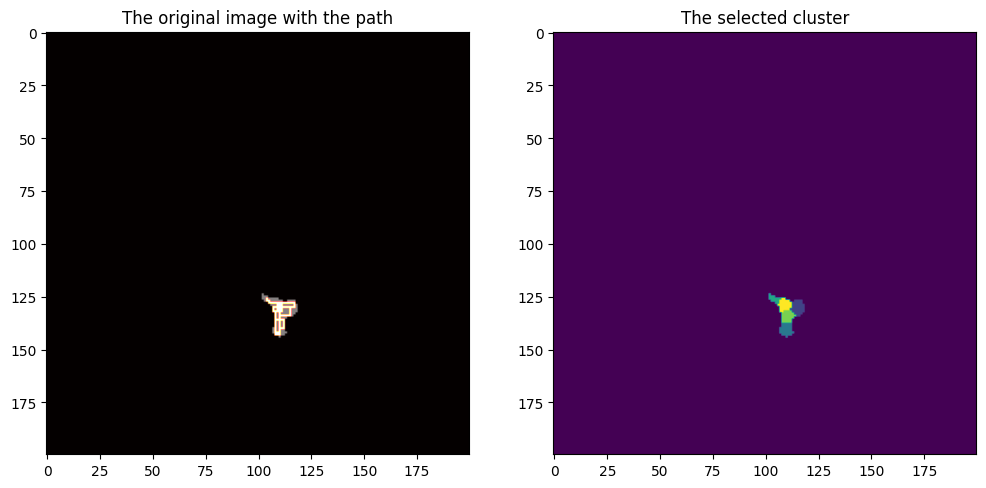

In [42]:
import matplotlib.pyplot as plt

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", set_of_pores_index[random_index_apply_pore])

# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(image_temp, cmap='gray')  # Mostrar a imagem original
axes[0].imshow(path, cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_index_apply_pore]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

### Calculating each path and show each path

In [44]:
from itertools import combinations
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
max_distance = 0
farthest_centers = None
# Iterar sobre todas as combinações possíveis de pares de centros
for (i, j) in combinations(range(len(centers_temp)), 2):
    p1, p2 = centers_temp[i], centers_temp[j]
    dist = euclidean_distance(p1, p2)
    if dist > max_distance:
        max_distance = dist
        farthest_centers = (p1, p2)
        farthest_centers_index = i
print("Maior distância:", max_distance)
print("Centros mais distantes:", farthest_centers)

Maior distância: 15.55698892256257
Centros mais distantes: (array([140.68571429, 109.82857143]), array([126.1875, 104.1875]))


In [45]:
save_dist_index = []
for dist, i, j in distances:
    temp_dist_index = dist, i, j
    save_dist_index.append(temp_dist_index)

In [46]:
save_dist_index[0:5]

[(5.6264837090242725, 2, 4),
 (5.688581832852017, 3, 4),
 (6.2022325324555165, 1, 3),
 (6.4173281920815874, 0, 4),
 (6.476446562587624, 0, 3)]

In [47]:
path = np.zeros_like(image_temp)
dist_test = abs(1000 - max_distance)
connected_centers = []
for dist, i, j in save_dist_index:
    centers_temp[i], centers_temp[j]
    dist_check = abs(dist - max_distance)
    if dist_check < dist_test:
        # Coordenadas dos centros dos clusters
        start_float = centers_temp[i]
        end_float = centers_temp[j]
        
        # Converter coordenadas de ponto flutuante para inteiras
        start = (int(round(start_float[0])), int(round(start_float[1])))
        end = (int(round(end_float[0])), int(round(end_float[1])))    
        # Encontrar o caminho de menor custo
        indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=False) # usar as coordenadas do centro de cada cluster, ou seja,
        indices = np.stack(indices, axis=-1)
        path[indices[0], indices[1]] = 1
        dist_test = dist_check

In [67]:
import numpy as np
from skimage.graph import route_through_array

# Initialize the path array and other variables
path = np.zeros_like(image_temp)
dist_test = abs(10*max_distance - max_distance)
connected_centers = []
list_of_path = []

for dist, i, j in save_dist_index:
    # Extract the center coordinates of the clusters
    center_i = centers_temp[i]
    center_j = centers_temp[j]
    
    # Check if these centers have already been connected
    if (i, j) in connected_centers or (j, i) in connected_centers:
        continue  # Skip this pair if already connected
    
    # Calculate the distance check value
    dist_check = abs(dist - max_distance)
    
    if dist_check < dist_test:
        # Coordinates of the cluster centers
        start_float = center_i
        end_float = center_j
        
        # Convert floating-point coordinates to integers
        start = (int(round(start_float[0])), int(round(start_float[1])))
        end = (int(round(end_float[0])), int(round(end_float[1])))
        
        # Find the lowest-cost path
        indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=True)
        indices = np.stack(indices, axis=-1)
        
        # Create a copy of the current path array to store the new path
        temp_path = np.zeros_like(path)
        temp_path[indices[0], indices[1]] = 1
        
        # Append the current path to the list of paths
        list_of_path.append(temp_path)
        
        # Update the main path array
        path[indices[0], indices[1]] = 1
        
        # Update the distance test value
        dist_test = dist_check
        
        # Add this pair to the list of connected centers
        connected_centers.append((i, j))

# Now list_of_path contains all the individual paths


The index of the cluster in resultados_kmeans: 86 8


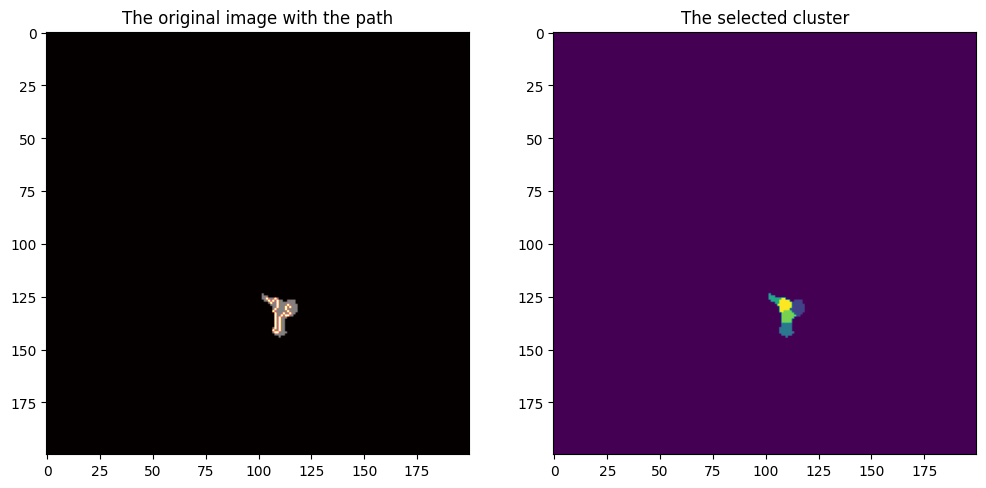

In [81]:
import matplotlib.pyplot as plt

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos
import random
random_number_path = random.randint(0, len(list_of_path)-1)
# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", set_of_pores_index[random_index_apply_pore], random_number_path)

# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(image_temp, cmap='gray')  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_number_path], cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_index_apply_pore]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

### Finding the farthest centers cluster

In [82]:
# Função para calcular a distância euclidiana entre dois pontos
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
max_distance = 0
farthest_centers = None
# Iterar sobre todas as combinações possíveis de pares de centros
for (i, j) in combinations(range(len(centers_temp)), 2):
    p1, p2 = centers_temp[i], centers_temp[j]
    dist = euclidean_distance(p1, p2)
    if dist > max_distance:
        max_distance = dist
        farthest_centers = (p1, p2)
        farthest_centers_index = i
print("Maior distância:", max_distance)
print("Centros mais distantes:", farthest_centers)

Maior distância: 15.55698892256257
Centros mais distantes: (array([140.68571429, 109.82857143]), array([126.1875, 104.1875]))


In [83]:
# Coordenadas dos centros dos clusters
start_float = farthest_centers[0]
end_float = farthest_centers[1]

# Converter coordenadas de ponto flutuante para inteiras
start = (int(round(start_float[0])), int(round(start_float[1])))
end = (int(round(end_float[0])), int(round(end_float[1])))

In [84]:
# Encontrar o caminho de menor custo
indices, weight = route_through_array(image_temp, start, end, geometric=False, fully_connected=False) # usar as coordenadas do centro de cada cluster, ou seja,
indices = np.stack(indices, axis=-1)
path = np.zeros_like(image_temp)
path[indices[0], indices[1]] = 1

The index of the cluster in resultados_kmeans: 86


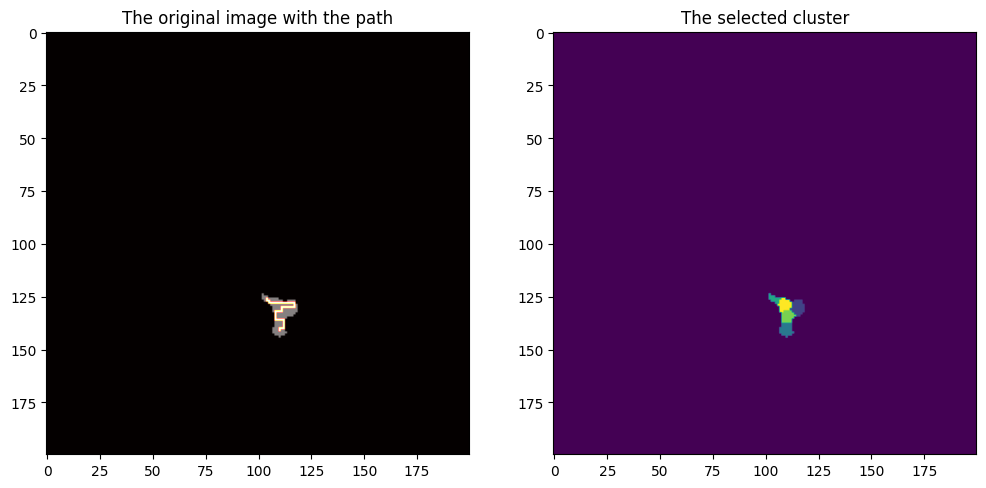

In [86]:
import matplotlib.pyplot as plt

# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", set_of_pores_index[random_index_apply_pore])

# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(image_temp, cmap='gray')  # Mostrar a imagem original
axes[0].imshow(path, cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(resultados_kmeans[set_of_pores_index[random_index_apply_pore]])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()